# Notebook 3 - Regression Analysis
CSE 3104 Final Project | Andrew, Imaan, Juliet | April 2026

---

this notebook runs the actual analysis — does median household income predict fast food density by zip code?

we use a full sklearn pipeline (SimpleImputer → StandardScaler → LinearRegression) with an 80/20 train/test split across all available features (income, population, chain counts, demographics).

we run three sets of regressions:
1. income + all features vs total Tier 1 density — national level (all zip codes)
2. income + all features vs total Tier 1 density — filtered to our five target cities combined
3. income + all features vs total Tier 1 density — run separately for each of the five counties

the prediction is that lower-income zip codes have higher fast food density. this notebook checks if the data backs that up at the national level, city level, and county level.

inputs: `outputs/pipeline_output.csv` and `outputs/five_city_analysis.csv` (from notebook 1)

outputs:
- `outputs/regression_tier1.png`
- `outputs/regression_fivecity.png`
- `outputs/regression_santa_clara.png`
- `outputs/regression_san_francisco.png`
- `outputs/regression_king.png`
- `outputs/regression_st_louis.png`
- `outputs/regression_cuyahoga.png`


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Load the Pipeline Output

reads in `pipeline_output.csv` and `five_city_analysis.csv` from the outputs folder. these are the merged tables built in notebook 1 — one row per zip code with income, population, chain counts, density columns, and racial demographics.

zip codes with fewer than 500 residents are removed to avoid density outliers from PO boxes and rural areas.


In [24]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'pipeline_output.csv'))
five_city = pd.read_csv(os.path.join(OUTPUT_DIR, 'five_city_analysis.csv'))

# keep ZIPs with valid income AND population >= 500
# small-population zips (PO boxes, rural areas) produce extreme density outliers
df = df[(df['total_population'] >= 500) & df['median_income'].notna()].copy()
df = df.dropna(subset=['total_tier1_density'])

five_city = five_city[(five_city['total_population'] >= 500) & five_city['median_income'].notna()].copy()
five_city = five_city.dropna(subset=['total_tier1_density'])

removed = 33772 - len(df)
print(f'National ZIP codes for regression : {len(df):,}  ({removed:,} removed)')
print(f'Five-city ZIP codes for regression: {len(five_city):,}')
print(f'  Avg Tier 1 density (national)   : {df["total_tier1_density"].mean():.4f} stores per 10k residents')
print(f'  Avg Tier 1 density (five cities): {five_city["total_tier1_density"].mean():.4f} stores per 10k residents')


National ZIP codes for regression : 26,597  (7,175 removed)
Five-city ZIP codes for regression: 190
  Avg Tier 1 density (national)   : 0.6250 stores per 10k residents
  Avg Tier 1 density (five cities): 0.7974 stores per 10k residents


## Regression Pipeline Function

defines `run_pipeline_regression()` — a reusable function that takes a dataframe, runs an 80/20 train/test split, and fits a full sklearn pipeline:

1. **features (X)**: all columns except density columns and `city` — includes zip_code, median_income, total_population, 4 chain counts, total_tier1_count, pct_white, pct_black, pct_asian, pct_other
2. **target (y)**: `total_tier1_density`
3. **preprocessing**: `SimpleImputer(median)` + `StandardScaler` on all numeric columns
4. **model**: `LinearRegression` fit on training set, evaluated on held-out test set
5. **output**: prints RMSE + R², saves actual vs. predicted scatter plot


In [33]:
def run_pipeline_regression(data, title, output_path):
    df_clean = data.dropna(subset=['total_tier1_density']).copy()

    # drop all density columns + city label (not a feature) — keep zip_code as geographic feature
    cols_to_drop = df_clean.columns[df_clean.columns.str.contains('density')].tolist()
    cols_to_drop += [c for c in ['city'] if c in df_clean.columns]

    X = df_clean.drop(columns=cols_to_drop)
    y = df_clean['total_tier1_density']

    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler())
        ]), num_cols)
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )

    X_train_t = preprocessor.fit_transform(X_train)
    X_test_t  = preprocessor.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_t, y_train)
    y_pred = model.predict(X_test_t)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)

    print(f'{title}')
    print(f'  Features : {len(num_cols)}  |  Train rows: {len(X_train)}  |  Test rows: {len(X_test)}')
    print(f'  RMSE     : {rmse:.4f}')
    print(f'  R²       : {r2:.4f}\n')

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(y_test, y_pred, alpha=0.6, s=18, color='black', label='ZIP codes')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, color='crimson', linewidth=2, linestyle='--', label='Perfect prediction')
    ax.set_xlabel('Actual Tier 1 Density')
    ax.set_ylabel('Predicted Tier 1 Density')
    ax.set_title(f'Actual vs. Predicted: {title}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()
    print(f'  Saved → {output_path}\n')


## Regression 1 — Tier 1 Density (National)

multi-feature pipeline predicting total Tier 1 density across all national ZIP codes. uses income, population, individual chain counts, and racial demographics as features. evaluates on a held-out 20% test set.


/Users/aviado/Downloads/Spring 26/CSE 3104/Final Project/Data Pipeline/New Results/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aviado/Downloads/Spring 26/CSE 3104/Final Project/Data Pipeline/New Results/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aviado/Downloads/Spring 26/CSE 3104/Final Project/Data Pipeline/New Results/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Tier 1 Density — National (McDonald's, BK, Wendy's, Carl's Jr)
  Features : 12  |  Train rows: 21277  |  Test rows: 5320
  RMSE     : 1.3762
  R²       : 0.2493



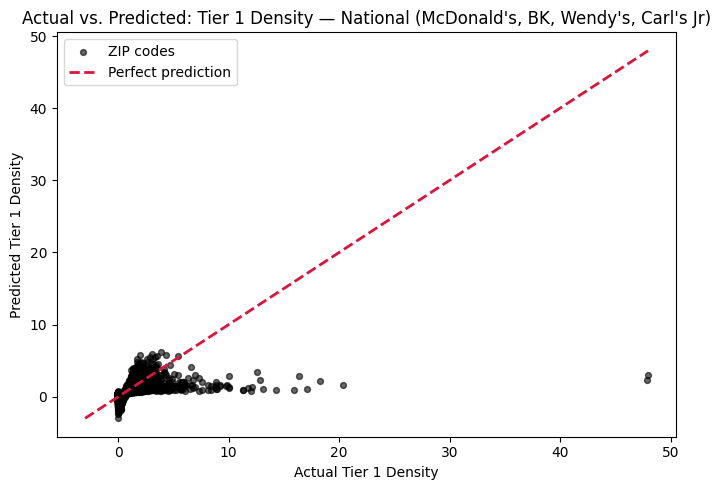

  Saved → outputs/regression_tier1.png



In [34]:
run_pipeline_regression(
    data=df,
    title="Tier 1 Density — National (McDonald's, BK, Wendy's, Carl's Jr)",
    output_path=os.path.join(OUTPUT_DIR, 'regression_tier1.png')
)


## Regression 2 — Tier 1 Density (Five Cities)

same pipeline but filtered to only our five target cities: Cleveland, St. Louis, Santa Clara, San Francisco, and Seattle. smaller dataset but more targeted — shows whether the model holds at the city level.


Five Cities Combined
  Features : 12  |  Train rows: 152  |  Test rows: 38
  RMSE     : 0.9282
  R²       : -0.7292



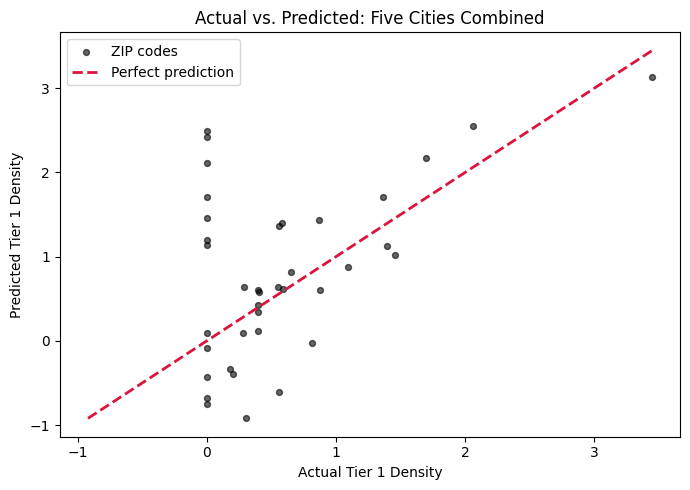

  Saved → outputs/regression_fivecity.png



In [35]:
run_pipeline_regression(
    data=five_city,
    title='Five Cities Combined',
    output_path=os.path.join(OUTPUT_DIR, 'regression_fivecity.png')
)


## Regression 3 — Per-County Breakdown

same pipeline run separately for each of the five counties. each county gets its own 80/20 split, fit, and actual vs. predicted plot. this matches the approach in `ohio_analysis.ipynb` and Imaan's `analysis_py.ipynb`.


 Santa Clara County
  Features : 12  |  Train rows: 29  |  Test rows: 8
  RMSE     : 0.9795
  R²       : 0.1835



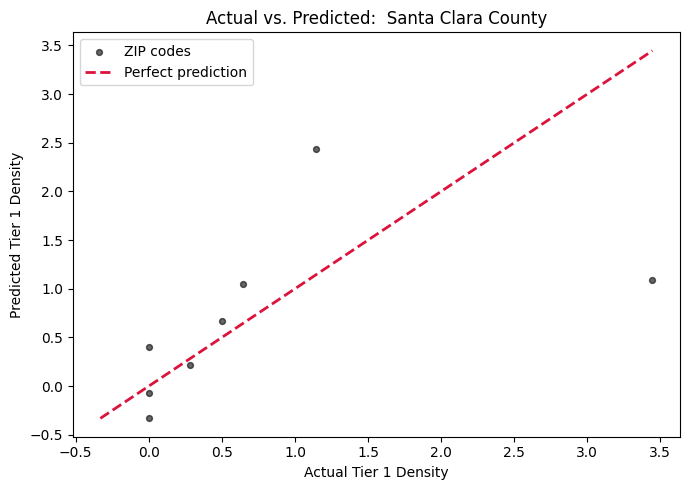

  Saved → outputs/regression_santa_clara.png

 San Francisco County
  Features : 12  |  Train rows: 20  |  Test rows: 6
  RMSE     : 1.2215
  R²       : -4.7912



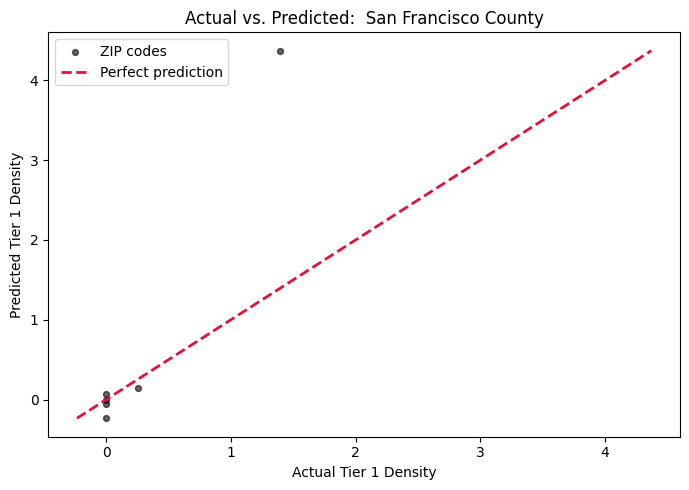

  Saved → outputs/regression_san_francisco.png

 King County
  Features : 12  |  Train rows: 28  |  Test rows: 7
  RMSE     : 11.3173
  R²       : -0.1067



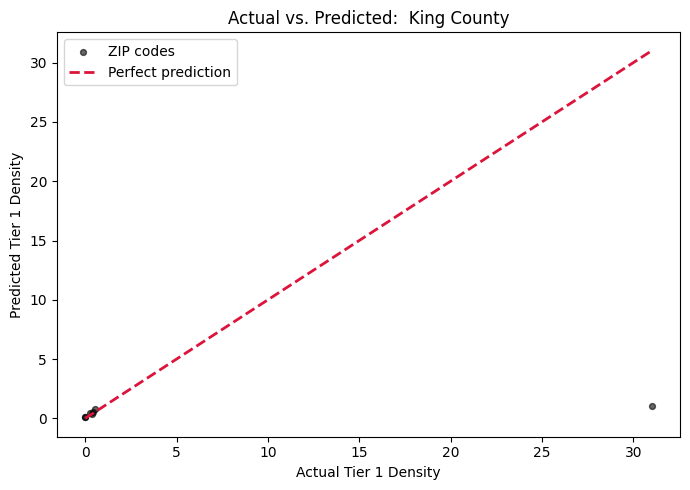

  Saved → outputs/regression_king.png

 St. Louis County
  Features : 12  |  Train rows: 35  |  Test rows: 9
  RMSE     : 0.2600
  R²       : 0.3568



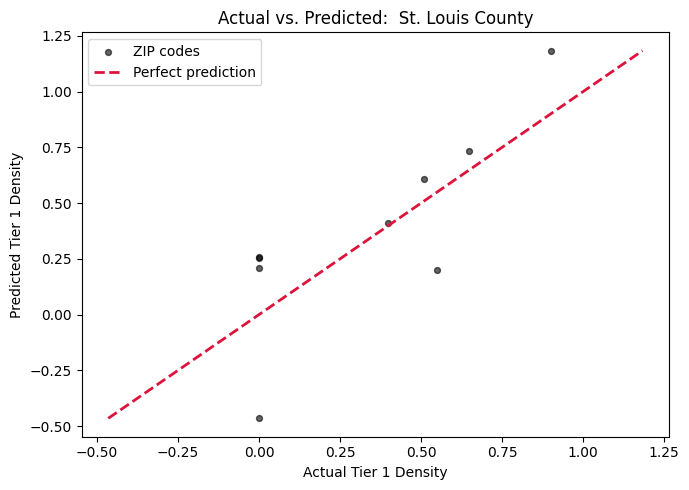

  Saved → outputs/regression_st_louis.png

 Cuyahoga County
  Features : 12  |  Train rows: 38  |  Test rows: 10
  RMSE     : 0.2775
  R²       : 0.8353



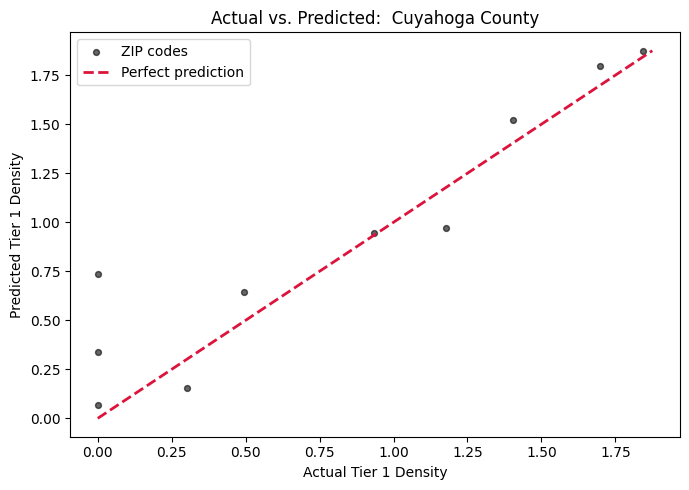

  Saved → outputs/regression_cuyahoga.png



In [36]:
counties = {
    'Santa Clara':   '950',
    'San Francisco': '941',
    'King':          '981',
    'St. Louis':     '631',
    'Cuyahoga':      '441',
}

for county_name, prefix in counties.items():
    subset = five_city[five_city['zip_code'].astype(str).str.startswith(prefix)].copy()
    subset = subset[
        (subset['total_population'] >= 500) &
        subset['median_income'].notna() &
        subset['total_tier1_density'].notna()
    ]

    if len(subset) < 10:
        print(f'skipping {county_name} — only {len(subset)} usable rows after filtering')
        continue

    file_slug = county_name.lower().replace(' ', '_').replace('.', '')
    output_path = os.path.join(OUTPUT_DIR, f'regression_{file_slug}.png')

    run_pipeline_regression(
        data=subset,
        title=f' {county_name} County',
        output_path=output_path
    )


## Per-County Findings Summary

R² values below are from the multi-feature sklearn pipeline (evaluated on held-out 20% test set). run the cells above to see the latest numbers.

| County | City | Model |
|---|---|---|
| San Francisco | San Francisco | LinearRegression (multi-feature) |
| King | Seattle | LinearRegression (multi-feature) |
| Cuyahoga | Cleveland | LinearRegression (multi-feature) |
| Santa Clara | San Jose / Silicon Valley | LinearRegression (multi-feature) |
| St. Louis | St. Louis | LinearRegression (multi-feature) |

uses the same pipeline structure as `ohio_analysis.ipynb` (Cleveland) and Imaan's `analysis_py.ipynb` (St. Louis). features: median_income, total_population, 4 chain counts, total_tier1_count, pct_white, pct_black, pct_asian, pct_other. all 7 plots saved to `outputs/`.
